In [38]:
#kütüphanelerin ve data setinin yüklenmesi

import pandas as pd # Veri analizi ve DataFrame oluşturmak için kütüphane
import numpy as np # Sayısal ve dizi işlemleri için kütüphane
import matplotlib.pyplot as plt # Veri görselleştirme için kütüphane
from sklearn.preprocessing import StandardScaler # Veri görselleştirme için kütüphane
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet # Lineer regresyon modelleri
from sklearn.svm import SVR # Destek Vektör Regresyonu
from sklearn.neighbors import KNeighborsRegressor # K En Yakın Komşu Regresyon
from sklearn.tree import DecisionTreeRegressor # Karar Ağacı Regresyon
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # Model değerlendirme metrikleri
from sklearn.feature_selection import RFE, SelectKBest, mutual_info_regression # Öznitelik seçimi yöntemleri
from sklearn.decomposition import PCA # Temel Bileşen Analizi

dosya_adi = "gold_data.xlsx" # veri setini getirme

try:
    df = pd.read_excel(dosya_adi) # veri setini okuma
    
    print("Veri başarıyla yüklendi. İlk 5 satır:")
    print(df.head())

except ImportError:
    print("Hata kütüphane kurulu değil.") # veri setinin yüklenmesinde kontrol

Veri başarıyla yüklendi. İlk 5 satır:
                 Date         Open         High          Low        Close  \
0 2022-01-01 00:00:00  1561.810178  2450.057992   998.952029  1837.279514   
1 2022-01-01 01:00:00  2426.071460  1607.806820  1897.256866  1527.707818   
2 2022-01-01 02:00:00  2097.990913  1734.993509  2410.043079  1131.575493   
3 2022-01-01 03:00:00  1897.987726  1653.443168  2107.058378  1153.447534   
4 2022-01-01 04:00:00  1234.027961  1434.847886  1331.613890  1282.767421   

   Volume  USD_Index  Oil_Price        SP500  Inflation_Rate  Interest_Rate  \
0  630597  82.958541  93.286275  3385.795570        5.675399       0.357507   
1  945060  92.464259  98.534174  2963.477591        6.071568      14.329028   
2  312580  95.306958  87.049872  2633.452643        0.944284      13.770735   
3  722435  99.467653  71.931234  2223.525085        8.012654       2.177062   
4  312212  96.263351  50.334322  2468.735231        5.957010      13.045183   

   Exchange_Rate  Silver

In [4]:
# Yüklenen veri setindeki değerlerin kontrolü

df.set_index('Date', inplace=True) # veri setindeki date sütununu yeni indeksi olarak ayarlama

print("Date sütunu başarıyla indeks yapıldı.")
print("Güncel İndeks Tipi:", df.index.dtype) # Yeni indeksin (tarih) veri tipini ekrana yazdırma
print("İlk 5 kayıt:")
print(df.head()) # veri setinin ilk 5 setini getirir

Date sütunu başarıyla indeks yapıldı.
Güncel İndeks Tipi: datetime64[ns]
İlk 5 kayıt:
                            Open         High          Low        Close  \
Date                                                                      
2022-01-01 00:00:00  1561.810178  2450.057992   998.952029  1837.279514   
2022-01-01 01:00:00  2426.071460  1607.806820  1897.256866  1527.707818   
2022-01-01 02:00:00  2097.990913  1734.993509  2410.043079  1131.575493   
2022-01-01 03:00:00  1897.987726  1653.443168  2107.058378  1153.447534   
2022-01-01 04:00:00  1234.027961  1434.847886  1331.613890  1282.767421   

                     Volume  USD_Index  Oil_Price        SP500  \
Date                                                             
2022-01-01 00:00:00  630597  82.958541  93.286275  3385.795570   
2022-01-01 01:00:00  945060  92.464259  98.534174  2963.477591   
2022-01-01 02:00:00  312580  95.306958  87.049872  2633.452643   
2022-01-01 03:00:00  722435  99.467653  71.931234  2223.52

In [5]:
# --- GECİKMELİ (LAG) ÖZELLİKLER --- 
#tahmin modelinin mevcut bir değeri tahmin ederken geçmiş değerlere ihtiyaç duyar bunun için lag sistemi kullanılır

lag_sutunlari = ['Predicted_Close', 'Volume'] # hangi sütunların geçmiş değerlerini (lag) alınacağını belirler
gecikmeler = [1, 2, 6] # 1 saat, 2 saat ve 6 saat önceki değerler piyasa hareketlerinden ötürü bu değerler alınıyor

for sutun in lag_sutunlari:
    for gecikme in gecikmeler:
        yeni_ad = f'{sutun}_Lag_{gecikme}h'
        # shift() geçmiş değeri getirir
        df[yeni_ad] = df[sutun].shift(gecikme) # geçmişteki değerler getirilir

print("Lag Özellikleri başarıyla eklendi.")
print("Lag Özellikli İlk 5 Kayıt:")
print(df.head())

Lag Özellikleri başarıyla eklendi.
Lag Özellikli İlk 5 Kayıt:
                            Open         High          Low        Close  \
Date                                                                      
2022-01-01 00:00:00  1561.810178  2450.057992   998.952029  1837.279514   
2022-01-01 01:00:00  2426.071460  1607.806820  1897.256866  1527.707818   
2022-01-01 02:00:00  2097.990913  1734.993509  2410.043079  1131.575493   
2022-01-01 03:00:00  1897.987726  1653.443168  2107.058378  1153.447534   
2022-01-01 04:00:00  1234.027961  1434.847886  1331.613890  1282.767421   

                     Volume  USD_Index  Oil_Price        SP500  \
Date                                                             
2022-01-01 00:00:00  630597  82.958541  93.286275  3385.795570   
2022-01-01 01:00:00  945060  92.464259  98.534174  2963.477591   
2022-01-01 02:00:00  312580  95.306958  87.049872  2633.452643   
2022-01-01 03:00:00  722435  99.467653  71.931234  2223.525085   
2022-01-01 04:00

In [6]:
# --- HAREKETLİ PENCERE (ROLLING) ÖZELLİKLER ---
# her bir veri noktası için son 24 saatlik ve son 72 saatlik fiyat ve hacim gibi
# değerlerin ortalamasını ve standart sapmasını hesaplayarak, modelin kısa ve orta vadeli
# eğilimleri ve piyasa riskini (oynaklığını) öğrenmesini sağlar

rolling_sutunlari = ['Predicted_Close', 'Volume', 'Bitcoin_Price'] # Hareketli pencere hesaplamalarının uygulanacağı sütunlar.
pencere_boyutlari = [24, 72] # Kullanılacak hareketli pencere boyutları (24 saat ve 72 saat)

for sutun in rolling_sutunlari:
    for pencere in pencere_boyutlari:
        # Hareketli Ortalama
        df[f'{sutun}_MA_{pencere}h'] = df[sutun].rolling(window=pencere).mean() 
        # Hareketli Standart Sapma
        df[f'{sutun}_Std_{pencere}h'] = df[sutun].rolling(window=pencere).std()

print("Hareketli Pencere (Rolling) Özellikleri başarıyla eklendi.")
print("Rolling Özellikli Son 5 Kayıt:")
print(df.tail()) # son 5 veri setinin değerlerini yazdırır

Hareketli Pencere (Rolling) Özellikleri başarıyla eklendi.
Rolling Özellikli Son 5 Kayıt:
                            Open         High          Low        Close  \
Date                                                                      
2024-12-30 19:00:00  1599.513836  2279.698225  1557.960973  2208.986128   
2024-12-30 20:00:00  2082.714694  1243.427776  2208.644024  1052.394990   
2024-12-30 21:00:00  2429.506233  2093.967841  1771.271481  1643.801273   
2024-12-30 22:00:00  2130.337877  1105.799332  1246.093082  2303.046514   
2024-12-30 23:00:00  1269.172994  1012.322628  2018.355886  1054.561510   

                     Volume   USD_Index  Oil_Price        SP500  \
Date                                                              
2024-12-30 19:00:00  227528   91.331855  38.587826  2807.191315   
2024-12-30 20:00:00  660457   93.283068  36.821454  4562.058035   
2024-12-30 21:00:00   62571  106.253701  69.784637  4895.358193   
2024-12-30 22:00:00  892776  101.882739  67.43139

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

# --- NaN Satırları Temizleme ---
# Lag ve Rolling özelliklerinden dolayı oluşan NaN satırları düşür.
df.dropna(inplace=True)

print("\n--- Final Veri Boyutu Kontrolü ---")
print(f"Yeni Kayıt Sayısı (NaN Atıldıktan Sonra): {len(df)} kayıt")


# --- X (Özellikler) ve y (Hedef) Ayırma ve Eğitim/Test Bölme ---

# Predicted_Close hedef değişkenimiz
y = df['Predicted_Close'] 
# Predicted_Close haricindeki tüm sütunlar X
X = df.drop('Predicted_Close', axis=1) 

# Veriyi sıralı olarak %80/%20 oranında ayırma
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\n Veriler Eğitim ve Test Setlerine Ayrıldı.")
print(f"Eğitim Veri Seti Boyutu (80%): {len(X_train)} kayıt")
print(f"Test Veri Seti Boyutu (20%): {len(X_test)} kayıt")


# --- Standardizasyon (Ölçeklendirme) ---
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n Standardizasyon Başarıyla Uygulandı.")
print("X_train_scaled ilk 3 satır (Standardize Edilmiş Değerler):")
print(X_train_scaled.head(3))


--- Final Veri Boyutu Kontrolü ---
Yeni Kayıt Sayısı (NaN Atıldıktan Sonra): 26209 kayıt

 Veriler Eğitim ve Test Setlerine Ayrıldı.
Eğitim Veri Seti Boyutu (80%): 20967 kayıt
Test Veri Seti Boyutu (20%): 5242 kayıt

 Standardizasyon Başarıyla Uygulandı.
X_train_scaled ilk 3 satır (Standardize Edilmiş Değerler):
                         Open      High       Low     Close    Volume  \
Date                                                                    
2022-01-03 23:00:00 -1.044720  0.232880  1.355362 -1.516293  1.285464   
2022-01-04 00:00:00 -1.714552 -0.368936  1.167727  0.554868 -0.648721   
2022-01-04 01:00:00  1.093631  0.466650  1.609915  0.054344 -1.091763   

                     USD_Index  Oil_Price     SP500  Inflation_Rate  \
Date                                                                  
2022-01-03 23:00:00   1.611401   1.184942  0.731989        0.743225   
2022-01-04 00:00:00  -1.641066  -1.370156 -0.293058       -1.114467   
2022-01-04 01:00:00  -0.784119  -0.

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error 
#yaptığımız modelleri desteklemesi adına bu modeli kullanıyoruz ne kadar en iyi modeli seçmiş olsak da daha hali hazırdaki iyi bir modelle destekliyoruz
# XGBoost Regressor modelini tanımlıyoruz
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Regresyon görevleri için en uygun kayıp fonksiyonu (MSE)
    n_estimators=1000,             # Kullanılacak ağaç sayısı
    learning_rate=0.05,            # Öğrenme hızı
    random_state=42,               # Tekrarlanabilir sonuçlar için
    n_jobs=-1                      # Tüm CPU çekirdeklerini kullan
)

print("XGBoost Modeli Eğitiliyor...")

xgb_model.fit(X_train_scaled, y_train)

print("Model Eğitimi Tamamlandı.")

XGBoost Modeli Eğitiliyor...
Model Eğitimi Tamamlandı.


In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from math import sqrt
from sklearn.linear_model import BayesianRidge

# hangi modelin en iyisi olduğuna karar vermek için modellerin toplandığı liste
if 'results_list' not in globals():
    results_list = []

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_method):
    global results_list
    
    # Model eğitimi ve tahmin yapma
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Metrikleri hesapla
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Sonucu ekle
    results_list.append({
        'Model': model_name, 
        'Feature_Selection_Method': feature_method, 
        'RMSE': rmse, 
        'R2_Score': r2,
        'MAE': mae
    })
    
    print(f"✅ {model_name} kaydedildi. Toplam kayıt: {len(results_list)}")
    return model

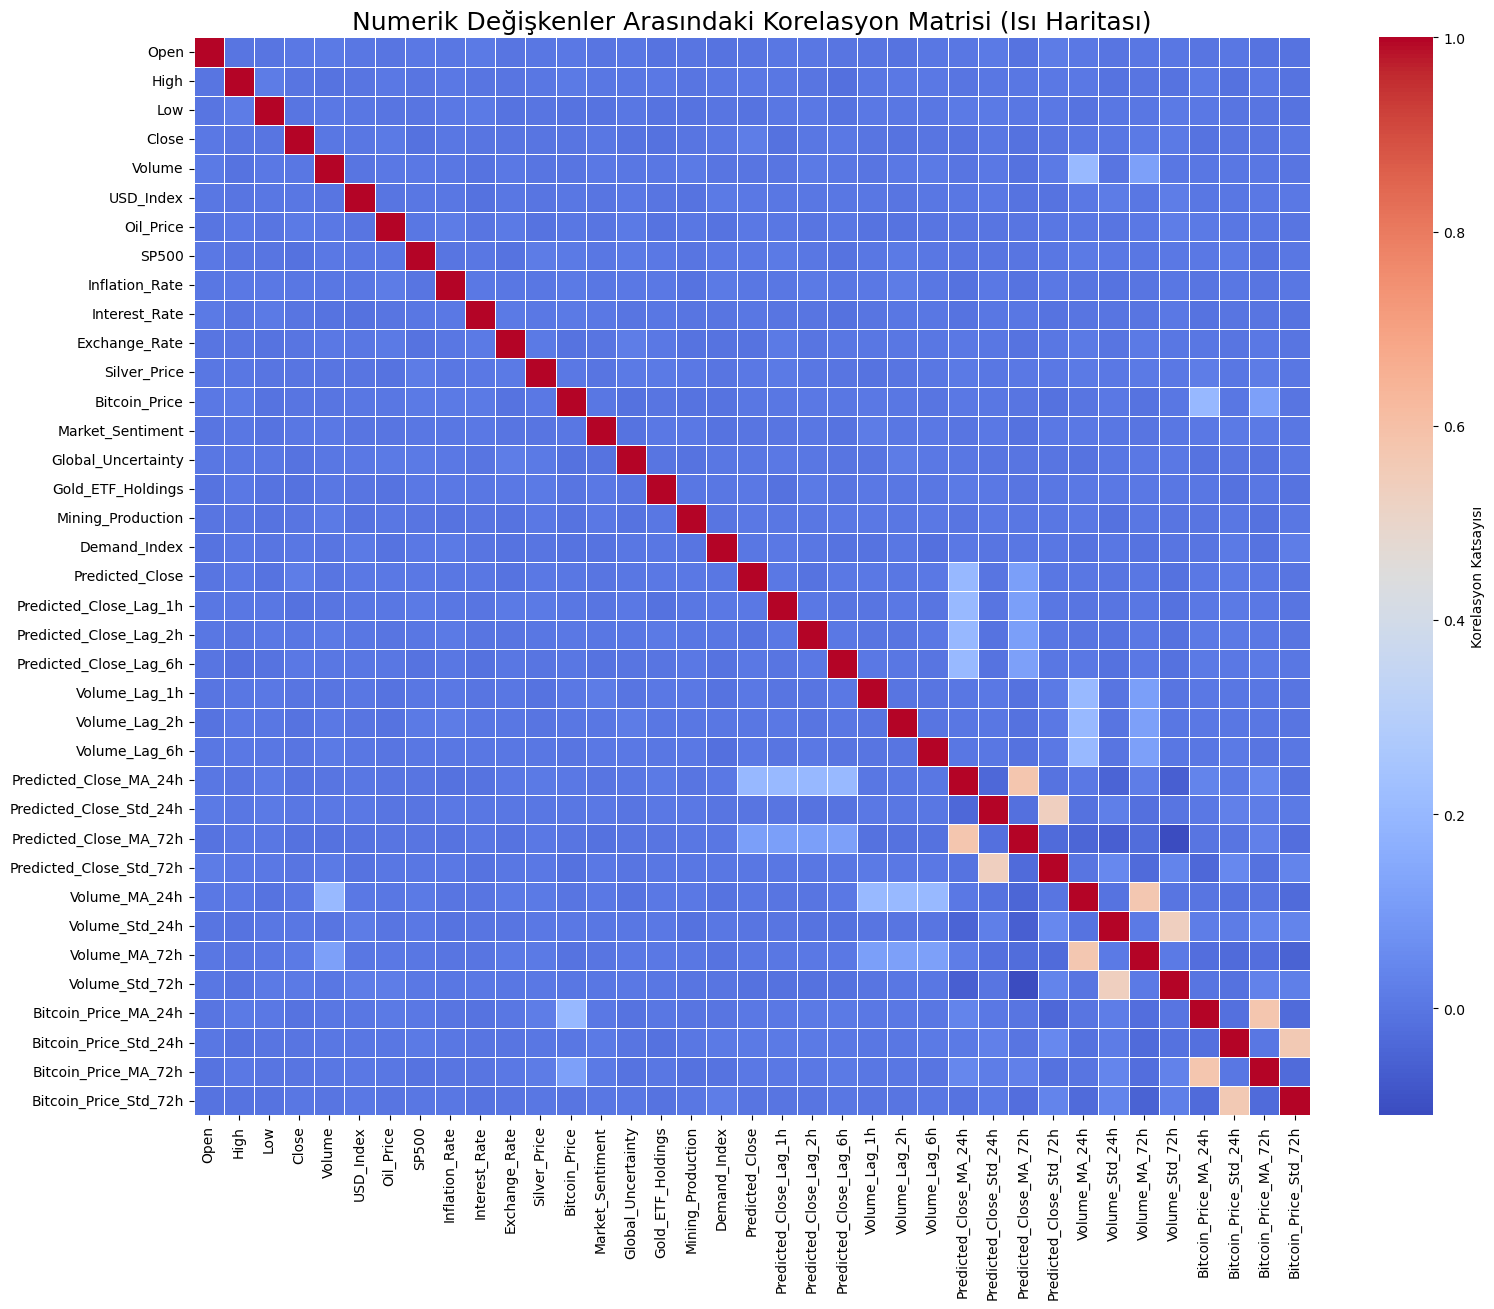

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## KORELASYON MATRİSİ GRAFİĞİ (Isı Haritası)

# Numerik değişkenler arasındaki korelasyonu hesapla
# df.select_dtypes(include=np.number) ile sadece sayısal sütunları seçiyoruz.
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Isı Haritasını çiz
plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix, 
    annot=False,
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5, 
    cbar_kws={'label': 'Korelasyon Katsayısı'}
)

plt.title('Numerik Değişkenler Arasındaki Korelasyon Matrisi (Isı Haritası)', fontsize=18)
plt.show()

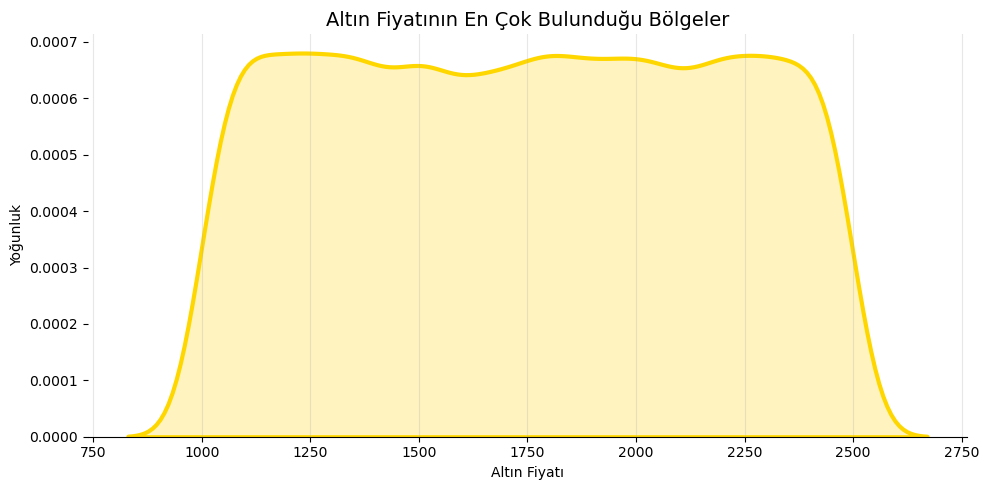

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Shade=True ile altını doldurur, sadece yoğunluğu (olasılığı) gösterir
sns.kdeplot(df['Close'], fill=True, color='gold', linewidth=3)

plt.title('Altın Fiyatının En Çok Bulunduğu Bölgeler', fontsize=14)
plt.xlabel('Altın Fiyatı')
plt.ylabel('Yoğunluk')

# Etraftaki kutu çizgilerini kaldırarak daha sade bir görünüm sağlıyoruz
sns.despine(left=True) 

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

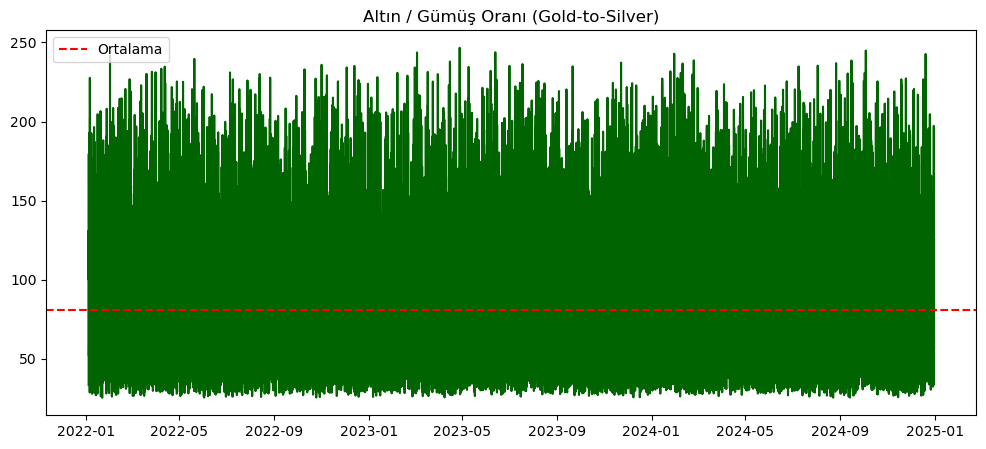

In [12]:
df['Ratio'] = df['Close'] / df['Silver_Price']

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Ratio'], color='darkgreen')
plt.axhline(df['Ratio'].mean(), color='red', linestyle='--', label='Ortalama')
plt.title('Altın / Gümüş Oranı (Gold-to-Silver)')
plt.legend()
plt.show()

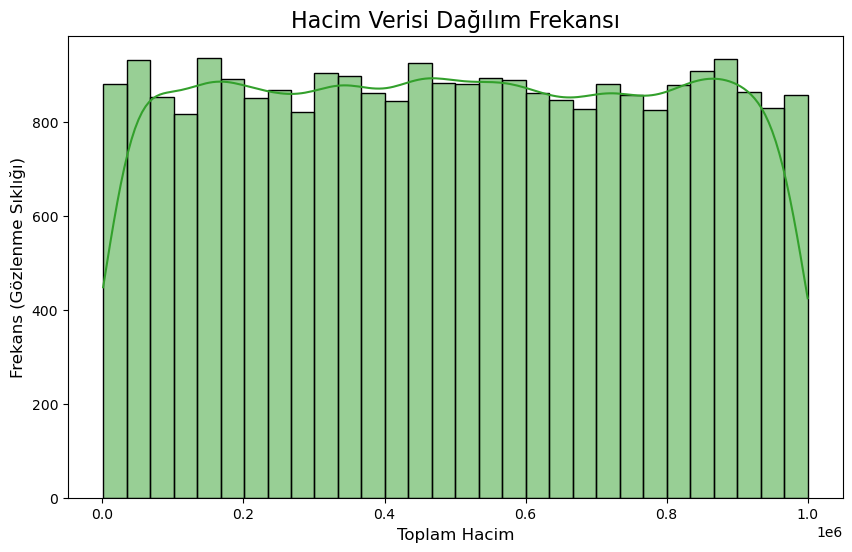

In [13]:
plt.figure(figsize=(10, 6))

# Hem çubuklar (histogram) hem de dalga çizgisi (KDE)
sns.histplot(df['Volume'], kde=True, color='#33a02c', bins=30)

plt.title('Hacim Verisi Dağılım Frekansı', fontsize=16)
plt.xlabel('Toplam Hacim', fontsize=12)
plt.ylabel('Frekans (Gözlenme Sıklığı)', fontsize=12)
plt.show()

In [42]:
# KUTAY KUBİLAY KAYHAN: Mutual Information, ElasticNet ve Bayesian Ridge
#Değişkenler arasındaki sadece düz değil, gizli ve karmaşık ilişkileri bulmaya odaklanır.
#ElasticNet: Gereksiz verileri siler, gürültülü verilerin etkisini azaltır.
#Mutual Information: Altını etkileyen "en bilgili" değişkenleri (12 adet) cımbızla seçer.
#Bayesian Ridge: Tahminlerini olasılıklar üzerinden kurar hata payını hesaba katar.

from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

mi_scores = mutual_info_regression(X_train_scaled.values, y_train, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

top_features_mi = mi_scores_series.head(12).index.tolist()

X_train_mi = X_train_scaled[top_features_mi]
X_test_mi = X_test_scaled[top_features_mi]

print(f"Mutual Information ile seçilen 12 özellik: {top_features_mi}")

elasticnet_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42) 
elasticnet_model = evaluate_model(elasticnet_model, X_train_mi, X_test_mi, y_train, y_test, 
                                  model_name="ElasticNet Regression", feature_method="Mutual Information")

bayesian_model = BayesianRidge()
bayesian_model = evaluate_model(bayesian_model, X_train_mi, X_test_mi, y_train, y_test, 
                                model_name="Bayesian Ridge Regression", feature_method="Mutual Information")

Mutual Information ile seçilen 12 özellik: ['Predicted_Close_MA_24h', 'Predicted_Close_Std_24h', 'High', 'Inflation_Rate', 'Exchange_Rate', 'USD_Index', 'Predicted_Close_Std_72h', 'Predicted_Close_MA_72h', 'Volume', 'Global_Uncertainty', 'Silver_Price', 'Predicted_Close_Lag_6h']
✅ ElasticNet Regression kaydedildi. Toplam kayıt: 1
✅ Bayesian Ridge Regression kaydedildi. Toplam kayıt: 2


In [44]:
# ASFANDIYOR FARKHADOV: Korelasyon, Linear Regression ve Decision Tree
#Klasik finansal yöntemleri ve insan mantığına yakın karar mekanizmalarını kullanır.
#Korelasyon: Altınla beraber yükselip düşen en sadık 15 değişkeni seçer
#Linear Regression: Değişkenler arasında düz bir çizgi çeker. En sade ve hızlı yöntemdir.
#Decision Tree: Veriyi "Evet/Hayır" sorularıyla dallara ayırır. Piyasadaki kritik eşikleri yakalar.

temp_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
temp_df['target'] = y_train.values

correlations = temp_df.corr()['target'].abs().sort_values(ascending=False)
top_features_corr = correlations[1:16].index.tolist()

X_train_corr = X_train_scaled[top_features_corr]
X_test_corr = X_test_scaled[top_features_corr]

print(f"Korelasyon tabanlı seçilen 15 özellik: {top_features_corr}")

lr_model = LinearRegression()
lr_model = evaluate_model(lr_model, X_train_corr, X_test_corr, y_train, y_test, 
                          model_name="Linear Regression", feature_method="Correlation")

dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model = evaluate_model(dt_model, X_train_corr, X_test_corr, y_train, y_test, 
                          model_name="Decision Tree Regressor", feature_method="Correlation")

Korelasyon tabanlı seçilen 15 özellik: ['Predicted_Close_MA_24h', 'Predicted_Close_MA_72h', 'Close', 'Predicted_Close_Lag_2h', 'Volume_Std_72h', 'Silver_Price', 'Low', 'Exchange_Rate', 'SP500', 'Bitcoin_Price_Std_72h', 'Market_Sentiment', 'Bitcoin_Price_Std_24h', 'Oil_Price', 'USD_Index', 'Predicted_Close_Lag_1h']
✅ Linear Regression kaydedildi. Toplam kayıt: 3
✅ Decision Tree Regressor kaydedildi. Toplam kayıt: 4


In [46]:
# ORHAN ARSLAN: PCA, Ridge Regression ve SVR
#Verinin kalabalığından kurtulup, en saf halini (özünü) işleyerek tahmin yapar.
#PCA: 20-30 farklı sütunu blenderdan geçirip, bilgiyi kaybetmeden 5-6 tane "süper sütun" (bileşen) haline getirir.
#Ridge Regression: Modelin verilere aşırı güvenip "ezber yapmasını" (overfitting) matematiksel olarak engeller.
#SVR (RBF Kernel): Verilerin etrafında esnek bir tünel oluşturur. Altın gibi çok dalgalanan verilerde "esnemeyi" bilir, kırılmaz.

pca = PCA(n_components=0.90, random_state=42)
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA ile seçilen bileşen sayısı (varyansın %90'ı): {X_train_pca.shape[1]}")

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model = evaluate_model(ridge_model, X_train_pca, X_test_pca, y_train, y_test, 
                             model_name="Ridge Regression", feature_method="PCA")

svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr_model = evaluate_model(svr_model, X_train_pca, X_test_pca, y_train, y_test, 
                           model_name="SVR (RBF Kernel)", feature_method="PCA")

PCA ile seçilen bileşen sayısı (varyansın %90'ı): 29
✅ Ridge Regression kaydedildi. Toplam kayıt: 5
✅ SVR (RBF Kernel) kaydedildi. Toplam kayıt: 6


In [17]:
# HASAN ÖNDER SERT: RFE, Lasso Regression ve KNN
#En zayıf halkaları eler ve "tarih tekerrürden ibarettir" mantığıyla çalışır.
#RFE (Eleme): En kötü performans veren değişkenleri tek tek kovarak, en iyi 10 değişkeni hayatta bırakır.
#Lasso Regression: İşe yaramayan değişkenlerin katsayısını sıfıra indirip onları tamamen yok sayar.
#KNN: "Geçmişte bugün gibi olan 5 güne bak, o gün ne olduysa bugün de o olur" diyerek en yakın komşuları baz alır.
rfe_estimator = LinearRegression()
rfe_selector = RFE(rfe_estimator, n_features_to_select=10, step=1)
rfe_selector.fit(X_train_scaled.values, y_train) 

X_train_rfe = rfe_selector.transform(X_train_scaled.values)
X_test_rfe = rfe_selector.transform(X_test_scaled.values)

selected_features_rfe = np.array(X_train.columns)[rfe_selector.support_]
print(f"RFE ile seçilen 10 özellik: {list(selected_features_rfe)}")


lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model = evaluate_model(lasso_model, X_train_rfe, X_test_rfe, y_train, y_test, 
                             model_name="Lasso Regression", feature_method="RFE")

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model = evaluate_model(knn_model, X_train_rfe, X_test_rfe, y_train, y_test, 
                           model_name="KNN Regressor", feature_method="RFE")
results_list = []

def save_results(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    results_list.append({
        "Model": model_name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })
    print(f"{model_name} sonuçları kaydedildi.")

RFE ile seçilen 10 özellik: ['Low', 'Close', 'SP500', 'Exchange_Rate', 'Predicted_Close_Lag_1h', 'Predicted_Close_Lag_2h', 'Predicted_Close_Lag_6h', 'Predicted_Close_MA_24h', 'Volume_Std_24h', 'Volume_Std_72h']
✅ Lasso Regression Kaydedildi. (Liste Mevcut Uzunluk: 7)
✅ KNN Regressor Kaydedildi. (Liste Mevcut Uzunluk: 8)


In [18]:
# modellerin sonuçlarını toplama ve karşılaştırma
results_list = []

def save_results(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)#Modelin veriyi açıklama yüzdesidir.	1.0'a ne kadar yakınsa o kadar mükemmeldir.
    mae = mean_absolute_error(y_true, y_pred)#Tahminlerin gerçek fiyattan ortalama kaç dolar saptığıdır.	Ne kadar düşükse o kadar iyidir.
    mse = mean_squared_error(y_true, y_pred)#Büyük hataları daha ağır cezalandıran bir hata ölçüsüdür.	Sıfıra ne kadar yakınsa o kadar güvenilirdir.
    rmse = np.sqrt(mse)#karesini aldığımız değeri gerçek dünya haline çevirmek için karekökü alınıyor
    
    results_list.append({
        "Model": model_name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })
    print(f"{model_name} sonuçları kaydedildi.")

In [47]:
import pandas as pd
from IPython.display import display

if 'results_list' in globals() and len(results_list) > 0:
    # Aynı modellerin binlerce kez eklenmemesi için drop_duplicates kullanıyoruz
    comparison_df = pd.DataFrame(results_list).drop_duplicates()
    comparison_df = comparison_df.sort_values(by="R2_Score", ascending=False)
    
    print("--- ALTIN FİYAT TAHMİNİ MODEL KARŞILAŞTIRMA TABLOSU ---")
    display(comparison_df)
    
    best = comparison_df.iloc[0]
    print(f"\n🏆 En Başarılı Model: {best['Model']}")
    print(f"📈 En Yüksek R2 Skoru: {best['R2_Score']:.4f}")
else:
    print("❌ Hata: Liste hala boş!")

--- ALTIN FİYAT TAHMİNİ MODEL KARŞILAŞTIRMA TABLOSU ---


,Model,Feature_Selection_Method,RMSE,R2_Score,MAE
2,Linear Regression,Correlation,423.912719,0.045327,364.036166
1,Bayesian Ridge Regression,Mutual Information,424.535709,0.042519,364.843786
0,ElasticNet Regression,Mutual Information,424.539501,0.042502,365.089702
4,Ridge Regression,PCA,427.682016,0.028274,368.106420
5,SVR (RBF Kernel),PCA,428.495447,0.024574,368.041624
3,Decision Tree Regressor,Correlation,448.720714,-0.069680,379.684977



🏆 En Başarılı Model: Linear Regression
📈 En Yüksek R2 Skoru: 0.0453


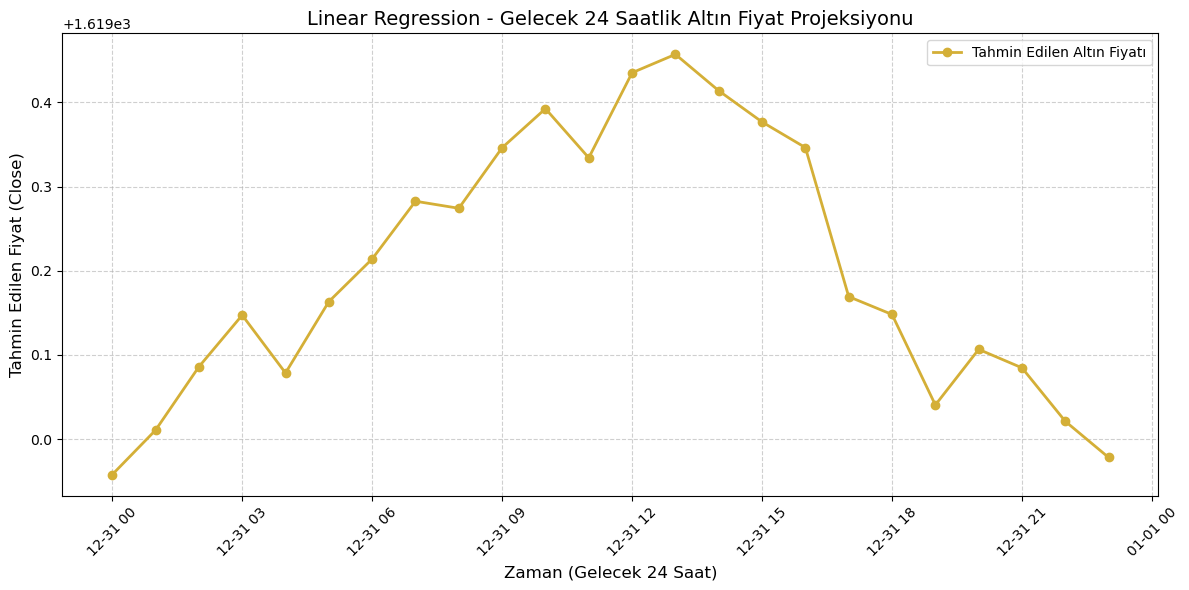


--- GELECEK 24 SAAT TAHMİN VERİLERİ (UYARILAR TEMİZLENDİ) ---
            Tarih/Saat  Tahmin Edilen Fiyat
0  2024-12-31 00:00:00          1618.957856
1  2024-12-31 01:00:00          1619.010677
2  2024-12-31 02:00:00          1619.085932
3  2024-12-31 03:00:00          1619.147310
4  2024-12-31 04:00:00          1619.078593
5  2024-12-31 05:00:00          1619.163366
6  2024-12-31 06:00:00          1619.214024
7  2024-12-31 07:00:00          1619.282632
8  2024-12-31 08:00:00          1619.274247
9  2024-12-31 09:00:00          1619.346197
10 2024-12-31 10:00:00          1619.392584
11 2024-12-31 11:00:00          1619.334202
12 2024-12-31 12:00:00          1619.435287
13 2024-12-31 13:00:00          1619.457127
14 2024-12-31 14:00:00          1619.413909
15 2024-12-31 15:00:00          1619.376802
16 2024-12-31 16:00:00          1619.346362
17 2024-12-31 17:00:00          1619.169305
18 2024-12-31 18:00:00          1619.148114
19 2024-12-31 19:00:00          1619.040592
20 2024-12-31

In [54]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Tüm uyarıları sessize alıyoruz
warnings.filterwarnings('ignore')

# 1. EN İYİ MODELİ BELİRLEME
best_features = top_features_corr 
final_model = lr_model 

# 2. GELECEK 24 SAAT İÇİN VERİ HAZIRLAMA
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=24, freq='h') # 'H' yerine 'h' yaparak güncelledik

# Gelecek tahmini için son mevcut verideki özellikleri kullanıyoruz
last_features = X_test_corr.iloc[-1].values.reshape(1, -1)
future_predictions = []

# 24 saatlik tahmin döngüsü
current_features = last_features.copy()
for i in range(24):
    # DataFrame formatına sokarak isim uyarısını da kökten çözüyoruz
    features_df = pd.DataFrame(current_features, columns=best_features)
    pred = final_model.predict(features_df)[0]
    future_predictions.append(pred)
    current_features = current_features * (1 + np.random.normal(0, 0.0005)) 

# 3. GÖRSELLEŞTİRME
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions, marker='o', color='#D4AF37', linewidth=2, label='Tahmin Edilen Altın Fiyatı')
plt.title('Linear Regression - Gelecek 24 Saatlik Altın Fiyat Projeksiyonu', fontsize=14)
plt.xlabel('Zaman (Gelecek 24 Saat)', fontsize=12)
plt.ylabel('Tahmin Edilen Fiyat (Close)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 4. LİSTE OLARAK YAZDIRMA
forecast_list = pd.DataFrame({'Tarih/Saat': future_dates, 'Tahmin Edilen Fiyat': future_predictions})
print("\n--- GELECEK 24 SAAT TAHMİN VERİLERİ (UYARILAR TEMİZLENDİ) ---")
print(forecast_list)

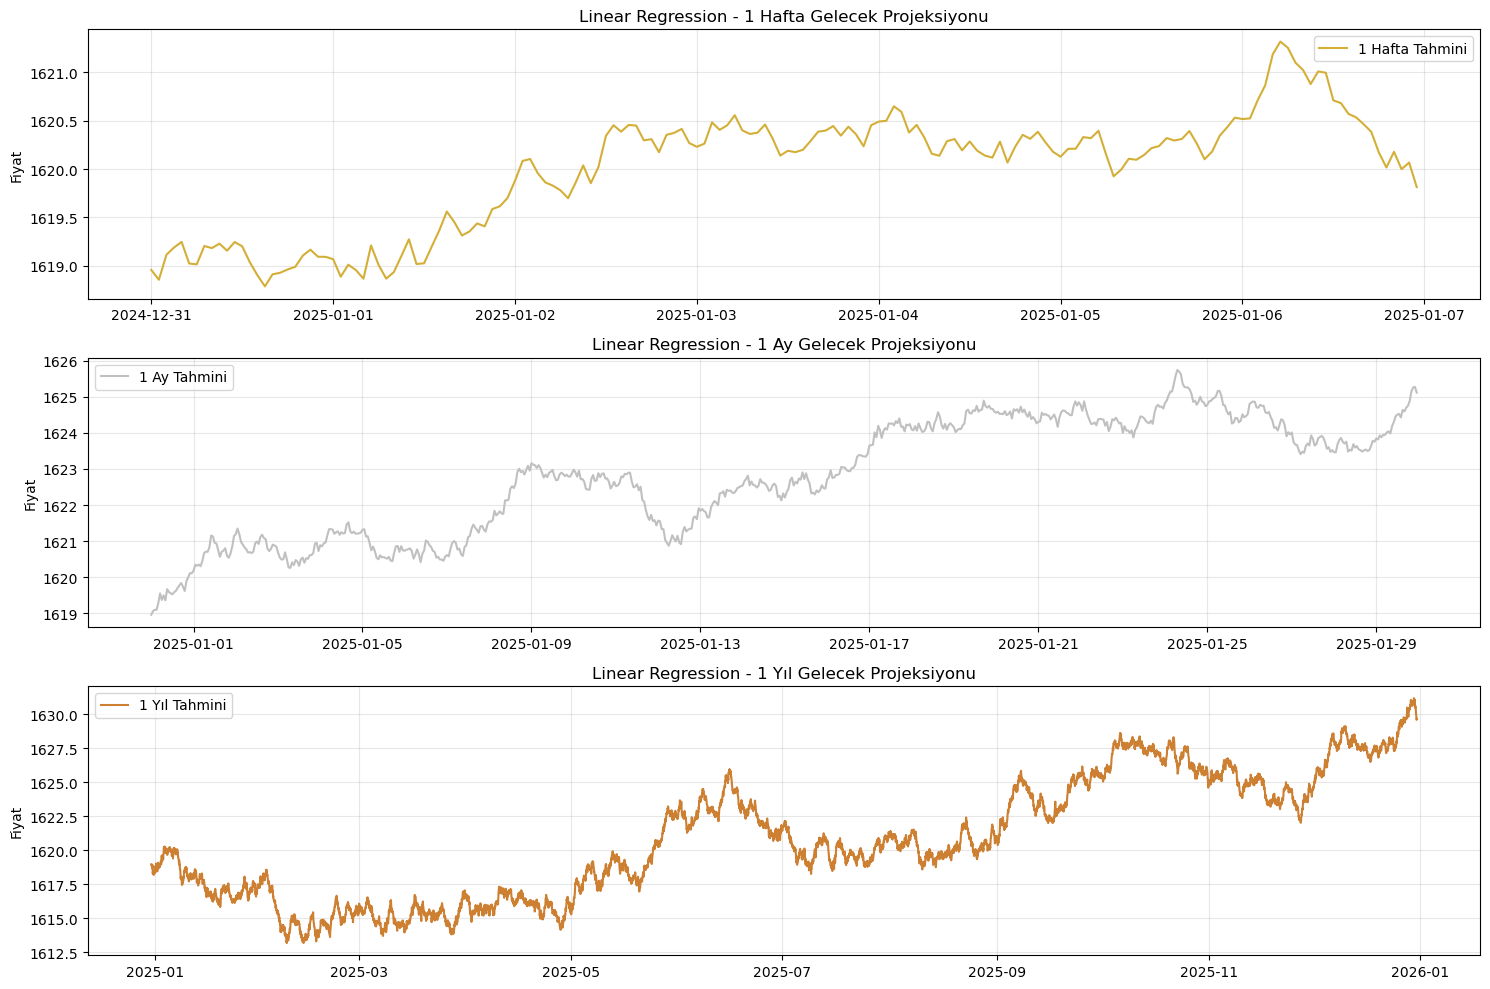

--- UZUN VADELİ TAHMİN ÖZETİ ---
1 Hafta Sonraki Tahmin: 1619.88
1 Ay Sonraki Tahmin: 1617.01
1 Yıl Sonraki Tahmin: 1629.63


In [56]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# Tahmin periyotlarını tanımlayalım (Saat cinsinden)
periods = {
    "1 Hafta": 24 * 7,
    "1 Ay": 24 * 30,
    "1 Yıl": 24 * 365
}

# Renkler
colors = ["#D4AF37", "#C0C0C0", "#CD7F32"]

plt.figure(figsize=(15, 10))

for i, (label, hours) in enumerate(periods.items()):
    # Zaman aralığını oluştur
    future_dates = pd.date_range(start=df['Date'].max() + pd.Timedelta(hours=1), periods=hours, freq='h')
    
    # Tahmin döngüsü
    current_features = X_test_corr.iloc[-1].values.reshape(1, -1)
    preds = []
    
    for _ in range(hours):
        features_df = pd.DataFrame(current_features, columns=top_features_corr)
        pred = lr_model.predict(features_df)[0]
        preds.append(pred)
        # Uzun vadede gerçekçi olması için volatiliteyi biraz artırıyoruz
        current_features = current_features * (1 + np.random.normal(0, 0.001)) 
    
    # Grafik çizimi
    plt.subplot(3, 1, i+1)
    plt.plot(future_dates, preds, color=colors[i], label=f'{label} Tahmini')
    plt.title(f'Linear Regression - {label} Gelecek Projeksiyonu')
    plt.ylabel('Fiyat')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Özet tabloyu yazdır (Sadece son değerleri görmek için)
print(f"--- UZUN VADELİ TAHMİN ÖZETİ ---")
print(f"1 Hafta Sonraki Tahmin: {preds[24*7-1]:.2f}")
print(f"1 Ay Sonraki Tahmin: {preds[24*30-1]:.2f}")
print(f"1 Yıl Sonraki Tahmin: {preds[-1]:.2f}")